# Predicting University Admission Likelihood

#### Import dependencies

In [19]:
#!pip install pandas scikit-learn matplotlib seaborn gradio
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

#### Load the dataset using pandas	

In [2]:
data = pd.read_csv(r"university_admissions.csv")

#### Print the first few rows to inspect the data	

In [3]:
data.head()

,GPA,Test Score,Extracurricular Activities,Volunteer Hours,Recommendation Letters,Essay Score,Accepted
0,3.40,1600,2,4,Good,Below Average,No
1,3.14,1600,10,56,Excellent,NaN,Yes
2,3.46,1600,6,27,Good,Average,Yes
3,3.81,1600,8,43,Good,Above Average,Yes
4,3.11,1600,1,16,Excellent,Very Weak,No


#### Check for any missing values

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   GPA                         200 non-null    float64
 1   Test Score                  200 non-null    int64  
 2   Extracurricular Activities  200 non-null    int64  
 3   Volunteer Hours             200 non-null    int64  
 4   Recommendation Letters      192 non-null    object 
 5   Essay Score                 192 non-null    object 
 6   Accepted                    200 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 11.1+ KB


In [5]:
data.isna().sum()

GPA                           0
Test Score                    0
Extracurricular Activities    0
Volunteer Hours               0
Recommendation Letters        8
Essay Score                   8
Accepted                      0
dtype: int64

#### Handle any missing values

In [6]:
categorical_cols = ['Recommendation Letters', 'Essay Score','Accepted']
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [7]:
data.isna().sum()

GPA                           0
Test Score                    0
Extracurricular Activities    0
Volunteer Hours               0
Recommendation Letters        0
Essay Score                   0
Accepted                      0
dtype: int64

#### Encode categorical columns

In [8]:
le = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])
    le[col] = encoder

#### Normalize or scale numeric columns

In [9]:
numerical_cols = ['GPA', 'Test Score', 'Extracurricular Activities', 'Volunteer Hours']
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

#### Generate summary statistics of the dataset	

In [10]:
data.describe()

,GPA,Test Score,Extracurricular Activities,Volunteer Hours,Recommendation Letters,Essay Score,Accepted
count,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,200.000000,200.000000,200.000000
mean,9.858780e-16,-1.471712e-14,8.881784e-17,-2.664535e-17,1.815000,2.460000,0.500000
std,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.147764,1.733037,0.501255
min,-2.825474e+00,-1.219943e+01,-1.939079e+00,-2.067553e+00,0.000000,0.000000,0.000000
25%,-7.217184e-01,9.707772e-02,-9.225240e-01,-6.635677e-01,1.000000,1.000000,0.000000
50%,3.892291e-02,9.707772e-02,9.403137e-02,-3.546909e-02,2.000000,2.000000,0.500000
75%,6.076907e-01,9.707772e-02,6.023090e-01,6.665234e-01,3.000000,4.000000,1.000000
max,2.245468e+00,9.707772e-02,3.143697e+00,2.513872e+00,3.000000,6.000000,1.000000


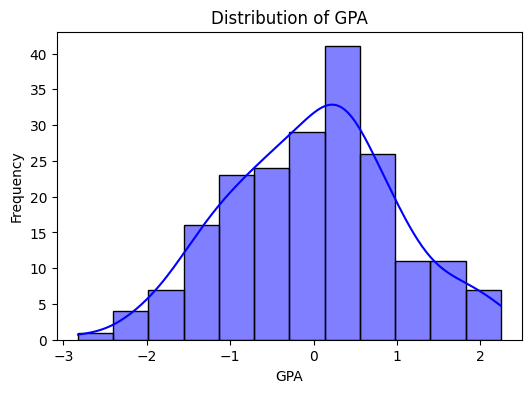

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(data["GPA"], kde=True, color="blue")
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")
plt.show()

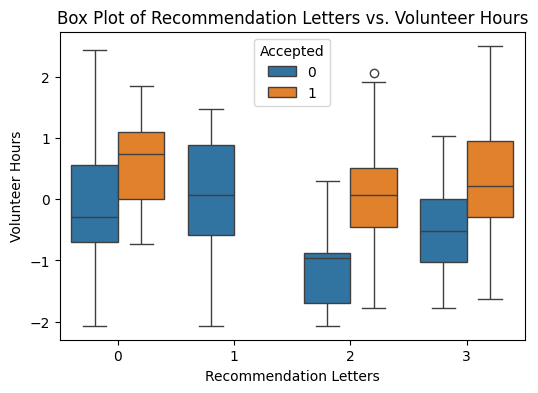

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data["Recommendation Letters"],  y=data["Volunteer Hours"], hue=data["Accepted"])
plt.title("Box Plot of Recommendation Letters vs. Volunteer Hours")
plt.xlabel("Recommendation Letters")
plt.ylabel("Volunteer Hours")
plt.show()

#### Separate features (X) and labels (y).

In [14]:
x = data.drop("Accepted", axis=1)
y = data["Accepted"]

#### Use train_test_split from sklearn to split the data into 80% training and 20% testing	

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Logistic Regression

In [20]:
lr = LogisticRegression()
lr.fit(x_train , y_train)
lr_y_pred = lr.predict(x_test)

print("Logistic Regression Metrics:")
print("Accuracy =", accuracy_score(y_test, lr_y_pred))
print("Precision =", precision_score(y_test, lr_y_pred))
print("Recall =", recall_score(y_test, lr_y_pred))
print("F1-Score =", f1_score(y_test, lr_y_pred))

Logistic Regression Metrics:
Accuracy = 0.85
Precision = 0.9
Recall = 0.8181818181818182
F1-Score = 0.8571428571428571


#### Random Forest Classifier

In [ ]:
rf = RandomForestClassifier()
rf.fit(x_train , y_train)
rf_y_pred = rf.predict(x_test)

print("Random Forest Classifier Metrics:")
print("Accuracy =", accuracy_score(y_test, rf_y_pred))
print("Precision =", precision_score(y_test, rf_y_pred))
print("Recall =", recall_score(y_test, rf_y_pred))
print("F1-Score =", f1_score(y_test, rf_y_pred))

Random Forest Classifier Metrics:
Accuracy = 0.875
Precision = 0.9473684210526315
Recall = 0.8181818181818182
F1-Score = 0.8780487804878049


#### Decision Tree Classifier

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_y_pred = dt.predict(x_test)

print("Decision Tree Classifier Metrics:")
print("Accuracy =", accuracy_score(y_test, dt_y_pred))
print("Precision =", precision_score(y_test, dt_y_pred))
print("Recall =", recall_score(y_test, dt_y_pred))
print("F1-Score =", f1_score(y_test, dt_y_pred))

Decision Tree Classifier Metrics:
Accuracy = 0.875
Precision = 0.9047619047619048
Recall = 0.8636363636363636
F1-Score = 0.8837209302325582


#### Generate the confusion matrix.	

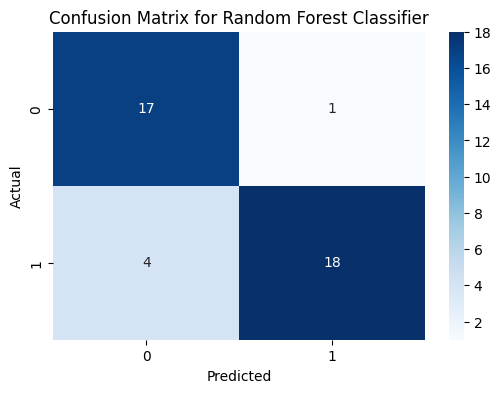

In [23]:
cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Random Forest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Use GridSearchCV or RandomizedSearchCV to find optimal parameters for models.	

In [25]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid_search.fit(x_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 20, 'n_estimators': 50}
0.8874912648497554


In [26]:
def predict(GPA, Test_Score, Extracurricular, Volunteer_Hours, Rec_Letters, Essay):
    try:
        input_data = pd.DataFrame({
            "GPA": [GPA],
            "Test Score": [Test_Score],
            "Extracurricular Activities": [Extracurricular],
            "Volunteer Hours": [Volunteer_Hours],
            "Recommendation Letters": [Rec_Letters],
            "Essay Score": [Essay]
        })
        
        input_data["Recommendation Letters"] = le["Recommendation Letters"].transform(input_data["Recommendation Letters"])
        input_data["Essay Score"] = le["Essay Score"].transform(input_data["Essay Score"])
        
        input_data[numerical_cols] = scaler.transform(input_data[numerical_cols])
        prediction = rf.predict(input_data)[0]
        
        result = "Accepted " if prediction == 1 else "Not Accepted "
        return f"Prediction: {result}"
    
    except Exception as e:
        return f"Error: {e}"

In [ ]:
gr.Interface(
    fn = predict,
    inputs = [
        gr.Number(label = "GPA"),
        gr.Number(label = "Test Score"),
        gr.Number(label = "Extracurricular Activities"),
        gr.Number(label = "Volunteer Hours"),
        gr.Dropdown(label = "Recommendation Letters" , choices = ["Average" , "Bad" , "Excellent" , "Good"]),
        gr.Dropdown(label = "Essay Score" , choices = ["Above Average" , "Average" , "Below Average" , "Good" , "Poor" , "Very Weak" , "Weak"]),
    ],
    outputs = "text",
    title = "University acceptence",
).launch()

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.
